# Redesigned Assignment: Metrics Analysis, Classification, and Density Estimation




In [ ]:
student_number = "401102791"   
Name = "Narges"             
Last_Name = "Vali"       

## Setup and Required Libraries

Run the following cells before starting the assignment.

**Hint:**  
If a package is missing, install it first and restart the kernel if needed.


In [ ]:
# Core libraries
import numpy as np
import pandas as pd


In [ ]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Scikit-learn datasets and utilities
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


In [ ]:
# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture


In [ ]:
# Metrics and mathematical utilities
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from scipy.stats import norm, multivariate_normal


# Part 1: Loading Iris and Building a DataFrame

## Question 1(4pts)

Load the Iris dataset using `load_iris`. Then create a DataFrame containing:

1. the four original features;
2. a `target` column;
3. a `species_name` column showing the species name of each sample.

Then report:

- the number of samples in each class;
- the mean of each feature for each species;
- the first five rows of the DataFrame.

### Hint
Use `iris.feature_names`, `iris.target`, and `iris.target_names`.


In [2]:
# TODO 1.1: Load the Iris dataset

from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()


In [3]:
# TODO 1.2: Create a clean DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["target"] = iris.target
df["species_name"] = df["target"].apply(lambda x: iris.target_names[x])

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# TODO 1.3: Report class counts

class_counts = df["species_name"].value_counts()

class_counts


species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
# TODO 1.4: Report mean of each feature per species
feature_means = df.groupby("species_name")[iris.feature_names].mean()

feature_means


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species_name,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


# Part 2: Visual Feature Analysis

## Question 2(3pts)

Draw a separate histogram for each feature, using different colors for different flower species. Then explain which features are more useful for separating the classes and why.

### Hint
Features with less overlap between class distributions are usually more useful for classification.


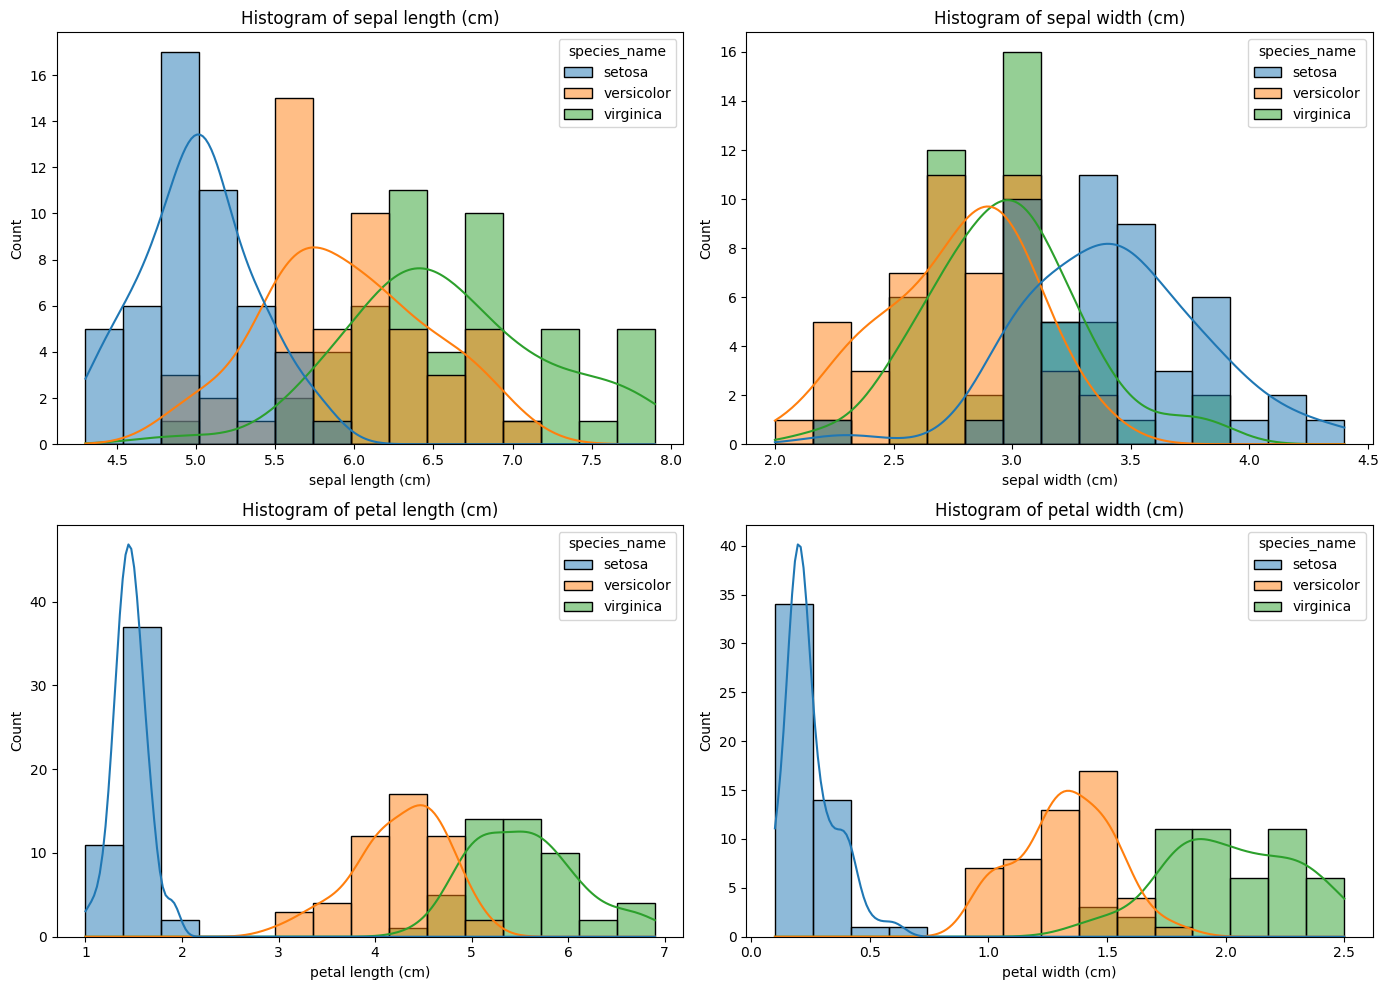

In [7]:
# TODO 2.1: Draw histograms for all features

import matplotlib.pyplot as plt
import seaborn as sns

features = iris.feature_names

plt.figure(figsize=(14, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=feature, hue="species_name", kde=True, bins=15)
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()


## Question 3(3pts)

Using a `pairplot`, choose the two features that you think have the strongest class-separation power. Then draw a scatter plot using only those two features and explain whether the classes can be separated by a linear decision boundary.

### Hint
In the pairplot, look for feature pairs where points from different classes form more clearly separated clusters.


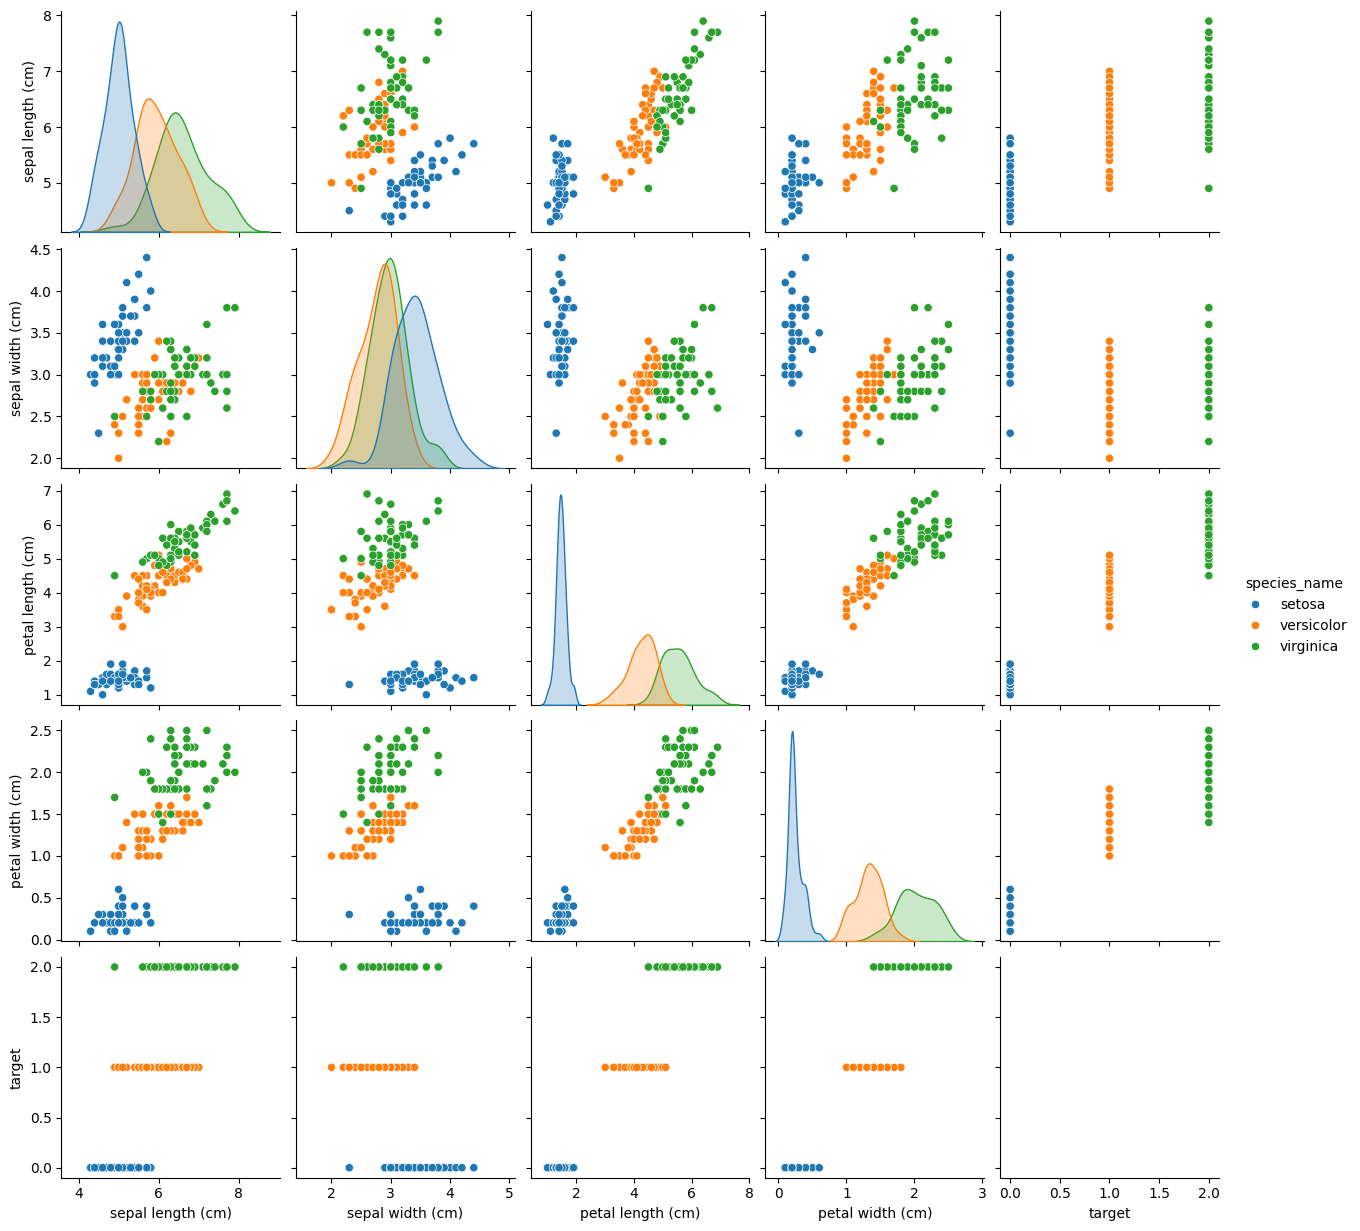

In [8]:
# TODO 3.1: Draw a pairplot

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="species_name")
plt.show()


In [9]:
# TODO 3.2: Select two visually strong features

selected_features = ['petal length (cm)', 'petal width (cm)']
print("Selected features:", selected_features)


Selected features: ['petal length (cm)', 'petal width (cm)']


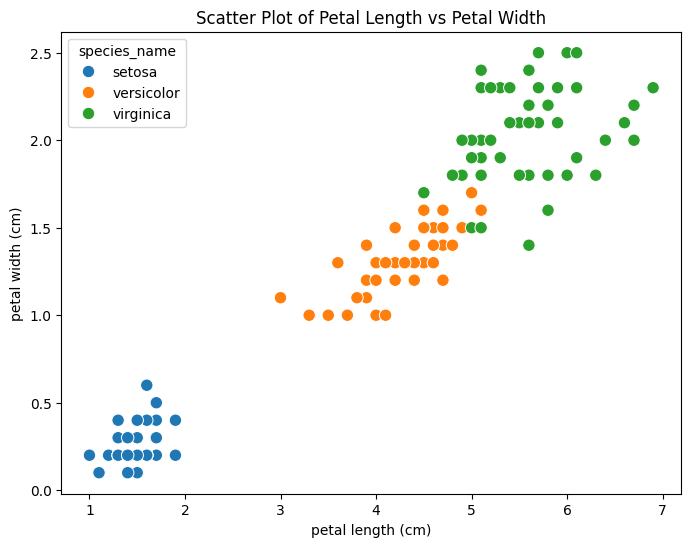

In [10]:
# TODO 3.3: Draw a scatter plot using the selected features

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species_name',
    s=80
)

plt.title("Scatter Plot of Petal Length vs Petal Width")
plt.show()


## Question 4(5pts)

For each feature and each class, compute the following values:

- median
- Q1
- Q3
- IQR

Then draw a boxplot for each feature and compare the numerical results with the plots.

### Hint
Use `groupby` and `quantile`.

The IQR is defined as:

\[
IQR = Q3 - Q1
\]


In [11]:
# TODO 4.1: Compute median, Q1, Q3, and IQR

feature_cols = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

results = []

for species, group in df.groupby('species_name'):
    for feature in feature_cols:
        q1 = group[feature].quantile(0.25)
        median = group[feature].median()
        q3 = group[feature].quantile(0.75)
        iqr = q3 - q1
        
        results.append({
            'species': species,
            'feature': feature,
            'Q1': q1,
            'median': median,
            'Q3': q3,
            'IQR': iqr
        })

stats_df = pd.DataFrame(results)

stats_df


,species,feature,Q1,median,Q3,IQR
0,setosa,sepal length (cm),4.800,5.00,5.200,0.400
1,setosa,sepal width (cm),3.200,3.40,3.675,0.475
2,setosa,petal length (cm),1.400,1.50,1.575,0.175
3,setosa,petal width (cm),0.200,0.20,0.300,0.100
4,versicolor,sepal length (cm),5.600,5.90,6.300,0.700
5,versicolor,sepal width (cm),2.525,2.80,3.000,0.475
6,versicolor,petal length (cm),4.000,4.35,4.600,0.600
7,versicolor,petal width (cm),1.200,1.30,1.500,0.300
8,virginica,sepal length (cm),6.225,6.50,6.900,0.675
9,virginica,sepal width (cm),2.800,3.00,3.175,0.375


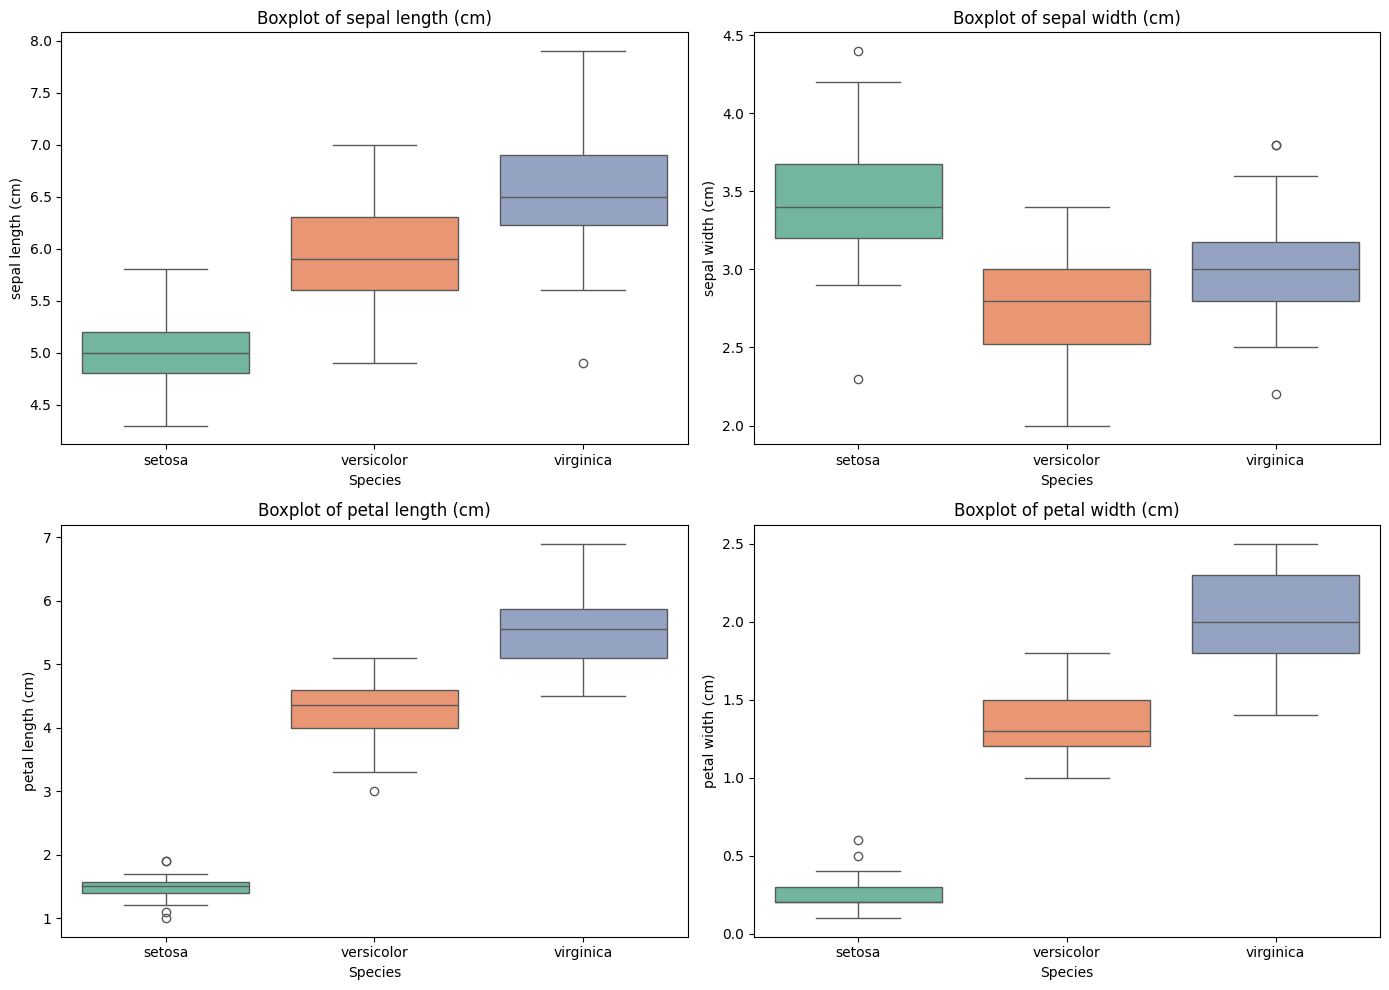

In [12]:
# TODO 4.2: Draw boxplots for all features

import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

plt.figure(figsize=(14, 10))

for i, feature in enumerate(feature_cols, 1):
    plt.subplot(2, 2, i)
    
    sns.boxplot(
        data=df,
        x='species_name',
        y=feature,
        hue='species_name',
        palette='Set2',
        legend=False
    )
    
    plt.title(f'Boxplot of {feature}')
    plt.xlabel('Species')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


# Part 3: Data Splitting with a DataLoader Class

## Question 5(10pts)

Implement a class named `IrisDataLoader` with the following capabilities:

1. receive train, validation, and test ratios from the user;
2. check that the sum of the ratios is equal to 1;
3. perform stratified splitting;
4. print class distributions before and after splitting;
5. return train, validation, and test data.

### Hint
To obtain separate validation and test sets, first split off the training set, then split the remaining data into validation and test sets.


In [13]:
# TODO 5.1: Define the DataLoader class

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

class IrisDataLoader:
    def __init__(self, df, feature_columns, target_column,
                 train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                 random_state=42):
        
        self.df = df
        self.feature_columns = feature_columns
        self.target_column = target_column
        
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = test_ratio
        self.random_state = random_state
        
        # Check that ratios sum to 1
        total_ratio = train_ratio + val_ratio + test_ratio
        
        if not np.isclose(total_ratio, 1.0):
            raise ValueError("Train, validation, and test ratios must sum to 1.")
        
        self.X = self.df[self.feature_columns]
        self.y = self.df[self.target_column]
    
    def print_class_distribution(self, y, name):
        print(f"\n{name} class distribution:")
        print(y.value_counts())
        print("\nPercentage:")
        print(y.value_counts(normalize=True) * 100)
    
    def split_data(self):
        # Print distribution before splitting
        self.print_class_distribution(self.y, "Original data")
        
        # First split: train and temporary data
        X_train, X_temp, y_train, y_temp = train_test_split(
            self.X,
            self.y,
            test_size=(self.val_ratio + self.test_ratio),
            random_state=self.random_state,
            stratify=self.y
        )
        
        # Second split: validation and test
        test_size_adjusted = self.test_ratio / (self.val_ratio + self.test_ratio)
        
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp,
            y_temp,
            test_size=test_size_adjusted,
            random_state=self.random_state,
            stratify=y_temp
        )
        
        # Print distributions after splitting
        self.print_class_distribution(y_train, "Training data")
        self.print_class_distribution(y_val, "Validation data")
        self.print_class_distribution(y_test, "Test data")
        
        return X_train, X_val, X_test, y_train, y_val, y_test


In [14]:
# TODO 5.2: Create a DataLoader object

feature_columns = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

target_column = 'species_name'

loader = IrisDataLoader(
    df=df,
    feature_columns=feature_columns,
    target_column=target_column,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42
)


In [15]:
# TODO 5.3: Split the data

X_train, X_val, X_test, y_train, y_val, y_test = loader.split_data()



Original data class distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Percentage:
species_name
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64

Training data class distribution:
species_name
versicolor    35
setosa        35
virginica     35
Name: count, dtype: int64

Percentage:
species_name
versicolor    33.333333
setosa        33.333333
virginica     33.333333
Name: proportion, dtype: float64

Validation data class distribution:
species_name
setosa        8
versicolor    7
virginica     7
Name: count, dtype: int64

Percentage:
species_name
setosa        36.363636
versicolor    31.818182
virginica     31.818182
Name: proportion, dtype: float64

Test data class distribution:
species_name
virginica     8
versicolor    8
setosa        7
Name: count, dtype: int64

Percentage:
species_name
virginica     34.782609
versicolor    34.782609
setosa        30.434783
Name: proportion,

In [16]:
# TODO 5.4: Check split shapes

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)


X_train shape: (105, 4)
X_val shape: (22, 4)
X_test shape: (23, 4)
y_train shape: (105,)
y_val shape: (22,)
y_test shape: (23,)


# Part 4: Gaussian Naive Bayes from Scratch

## Question 6(10pts)

Implement a `Gaussian Naive Bayes` model from scratch. Then compare its result with `sklearn.naive_bayes.GaussianNB`.

Requirements:

1. compute the mean and variance of each feature for each class;
2. compute the prior probability of each class;
3. add a small `epsilon` value to the variance;
4. perform prediction using log-probabilities.

### Hint
To avoid numerical underflow, sum log-probabilities instead of multiplying probabilities.


In [17]:
# TODO 6.1: Define Custom Gaussian Naive Bayes

import numpy as np

class CustomGaussianNB:
    def __init__(self, epsilon=1e-9):
        self.epsilon = epsilon
        self.classes = None
        self.means = {}
        self.variances = {}
        self.priors = {}
    
    def fit(self, X, y):
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y)
        
        # Get unique classes
        self.classes = np.unique(y)
        
        for c in self.classes:
            # Select samples of class c
            X_c = X[y == c]
            
            # Mean of each feature for class c
            self.means[c] = np.mean(X_c, axis=0)
            
            # Variance of each feature for class c + epsilon
            self.variances[c] = np.var(X_c, axis=0) + self.epsilon
            
            # Prior probability of class c
            self.priors[c] = X_c.shape[0] / X.shape[0]
        
        return self
    
    def _log_gaussian_probability(self, x, mean, variance):
        # Gaussian log probability:
        # log P(x|class) = -0.5 * log(2*pi*variance) - ((x-mean)^2 / (2*variance))
        return -0.5 * np.log(2 * np.pi * variance) - ((x - mean) ** 2) / (2 * variance)
    
    def _predict_single(self, x):
        log_posteriors = []
        
        for c in self.classes:
            # log prior
            log_prior = np.log(self.priors[c])
            
            # sum of log likelihoods for all features
            log_likelihood = np.sum(
                self._log_gaussian_probability(
                    x,
                    self.means[c],
                    self.variances[c]
                )
            )
            
            # log posterior
            log_posterior = log_prior + log_likelihood
            log_posteriors.append(log_posterior)
        
        # Return class with highest log posterior
        return self.classes[np.argmax(log_posteriors)]
    
    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])



In [18]:
# TODO 6.2: Train the custom model

custom_gnb = CustomGaussianNB(epsilon=1e-9)

custom_gnb.fit(X_train, y_train)

custom_predictions = custom_gnb.predict(X_test)



In [19]:
# TODO 6.3: Train sklearn GaussianNB

from sklearn.naive_bayes import GaussianNB

sklearn_gnb = GaussianNB()

sklearn_gnb.fit(X_train, y_train)

sklearn_predictions = sklearn_gnb.predict(X_test)



In [20]:
# TODO 6.4: Compare accuracies

from sklearn.metrics import accuracy_score

custom_accuracy = accuracy_score(y_test, custom_predictions)
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)

print("Custom GaussianNB Accuracy:", custom_accuracy)
print("Sklearn GaussianNB Accuracy:", sklearn_accuracy)

print("\nCustom Predictions:")
print(custom_predictions)

print("\nSklearn Predictions:")
print(sklearn_predictions)

print("\nTrue Labels:")
print(np.array(y_test))



Custom GaussianNB Accuracy: 0.9565217391304348
Sklearn GaussianNB Accuracy: 0.9565217391304348

Custom Predictions:
['setosa' 'setosa' 'versicolor' 'versicolor' 'virginica' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa' 'versicolor'
 'virginica' 'setosa' 'versicolor' 'virginica' 'setosa']

Sklearn Predictions:
['setosa' 'setosa' 'versicolor' 'versicolor' 'virginica' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa' 'versicolor'
 'virginica' 'setosa' 'versicolor' 'virginica' 'setosa']

True Labels:
[np.str_('setosa') np.str_('setosa') np.str_('virginica')
 np.str_('versicolor') np.str_('virginica') np.str_('virginica')
 np.str_('versicolor') np.str_('virginica') np.str_('setosa')
 np.str_('versicolor') np.str_('versicolor') np.str_('setosa')
 np.str_('versicolor') np.str_('virginica') np.str_('versicolo

# Part 5: Gaussian Bayes Classifier with Shared and Class-Specific Covariance

## Question 7(10pts)

Implement a Gaussian Bayes Classifier with two modes:

1. `covariance_type="tied"`: all classes share one covariance matrix;
2. `covariance_type="full"`: each class has its own covariance matrix.

Then compare the results with `LinearDiscriminantAnalysis` and `QuadraticDiscriminantAnalysis`.

### Hint
- The `tied` mode is similar to the idea behind LDA and produces linear decision boundaries.
- The `full` mode is similar to the idea behind QDA and can produce nonlinear decision boundaries.
- For numerical stability, add a small value to the diagonal of the covariance matrix.


In [21]:
# TODO 7.1: Define Gaussian Bayes Classifier

import numpy as np

class GaussianBayesClassifier:
    def __init__(self, covariance_type="tied", epsilon=1e-6):
        """
        covariance_type:
            "tied": shared covariance matrix for all classes
            "full": separate covariance matrix for each class
        """
        self.covariance_type = covariance_type
        self.epsilon = epsilon
        
        self.classes = None
        self.means = {}
        self.priors = {}
        self.covariances = {}
        self.shared_covariance = None
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        
        # Compute class means and priors
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / n_samples
        
        if self.covariance_type == "tied":
            # Shared covariance matrix
            shared_cov = np.zeros((n_features, n_features))
            
            for c in self.classes:
                X_c = X[y == c]
                centered = X_c - self.means[c]
                shared_cov += centered.T @ centered
            
            shared_cov = shared_cov / n_samples
            
            # Add epsilon to diagonal for numerical stability
            shared_cov += self.epsilon * np.eye(n_features)
            
            self.shared_covariance = shared_cov
        
        elif self.covariance_type == "full":
            # Class-specific covariance matrices
            for c in self.classes:
                X_c = X[y == c]
                centered = X_c - self.means[c]
                
                cov = (centered.T @ centered) / X_c.shape[0]
                
                # Add epsilon to diagonal for numerical stability
                cov += self.epsilon * np.eye(n_features)
                
                self.covariances[c] = cov
        
        else:
            raise ValueError("covariance_type must be either 'tied' or 'full'")
        
        return self
    
    def _log_multivariate_gaussian(self, x, mean, covariance):
        """
        Compute log probability of multivariate Gaussian distribution.
        """
        n_features = len(x)
        
        diff = x - mean
        
        # log determinant
        sign, log_det = np.linalg.slogdet(covariance)
        
        if sign <= 0:
            log_det = np.log(np.linalg.det(covariance + self.epsilon * np.eye(n_features)))
        
        # quadratic term
        inv_cov = np.linalg.inv(covariance)
        quadratic_term = diff.T @ inv_cov @ diff
        
        log_prob = -0.5 * (
            n_features * np.log(2 * np.pi)
            + log_det
            + quadratic_term
        )
        
        return log_prob
    
    def _predict_single(self, x):
        log_posteriors = []
        
        for c in self.classes:
            mean = self.means[c]
            prior = self.priors[c]
            
            if self.covariance_type == "tied":
                covariance = self.shared_covariance
            else:
                covariance = self.covariances[c]
            
            log_prior = np.log(prior)
            log_likelihood = self._log_multivariate_gaussian(x, mean, covariance)
            
            log_posterior = log_prior + log_likelihood
            log_posteriors.append(log_posterior)
        
        return self.classes[np.argmax(log_posteriors)]
    
    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])



In [22]:
# TODO 7.2: Prepare models for comparison

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

models = {
    "Custom Gaussian Bayes - tied": GaussianBayesClassifier(covariance_type="tied"),
    "Custom Gaussian Bayes - full": GaussianBayesClassifier(covariance_type="full"),
    "Sklearn LDA": LinearDiscriminantAnalysis(),
    "Sklearn QDA": QuadraticDiscriminantAnalysis()
}


In [23]:
# TODO 7.3: Train and evaluate all models

from sklearn.metrics import accuracy_score

results = {}

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Compute accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Store results
    results[model_name] = acc
    
    print(model_name)
    print("Accuracy:", acc)
    print("Predictions:")
    print(y_pred)
    print("-" * 50)


Custom Gaussian Bayes - tied
Accuracy: 1.0
Predictions:
['setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa' 'versicolor'
 'virginica' 'setosa' 'versicolor' 'virginica' 'setosa']
--------------------------------------------------
Custom Gaussian Bayes - full
Accuracy: 1.0
Predictions:
['setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa' 'versicolor'
 'virginica' 'setosa' 'versicolor' 'virginica' 'setosa']
--------------------------------------------------
Sklearn LDA
Accuracy: 1.0
Predictions:
['setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa' 'versicolor'


# Part 6: Selecting the Best k in KNN

## Question 8(15pts)

Train KNN models for the following values:


k in {1, 3, 5, 7, 9, 11}


For each value of k, compute accuracy and macro-F1 on the validation set. Then choose the best k and report its final performance on the test set.

### Hint
For KNN, it is better to standardize the features because the model is based on distances.


In [24]:
# TODO 8.1: Define candidate k values

k_values = [1, 3, 5, 7, 9, 11]



In [25]:
# TODO 8.2: Train and validate KNN models

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

validation_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_val_pred = knn.predict(X_val_scaled)
    
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')
    
    validation_results[k] = {
        "accuracy": val_accuracy,
        "macro_f1": val_f1
    }
    
    print(f"k = {k}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro-F1: {val_f1:.4f}")
    print("-" * 40)



k = 1
Validation Accuracy: 0.9091
Validation Macro-F1: 0.9028
----------------------------------------
k = 3
Validation Accuracy: 0.9091
Validation Macro-F1: 0.9028
----------------------------------------
k = 5
Validation Accuracy: 0.9091
Validation Macro-F1: 0.9028
----------------------------------------
k = 7
Validation Accuracy: 0.9091
Validation Macro-F1: 0.9028
----------------------------------------
k = 9
Validation Accuracy: 0.9091
Validation Macro-F1: 0.9028
----------------------------------------
k = 11
Validation Accuracy: 0.9091
Validation Macro-F1: 0.9028
----------------------------------------


In [26]:
# TODO 8.3: Select the best k

best_k = max(validation_results, key=lambda k: validation_results[k]["macro_f1"])

print("Best k:", best_k)
print("Best validation result:", validation_results[best_k])



Best k: 1
Best validation result: {'accuracy': 0.9090909090909091, 'macro_f1': 0.9027777777777778}


In [32]:
# TODO 8.4: Train the final KNN model

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Convert everything to numpy arrays
X_train_np = np.array(X_train)
X_val_np = np.array(X_val)
X_test_np = np.array(X_test)

y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

# Combine train and validation sets
X_train_final = np.vstack([X_train_np, X_val_np])
y_train_final = np.hstack([y_train_np, y_val_np])

# Refit scaler on combined training data
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_scaled_final = final_scaler.transform(X_test_np)

# Train final model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_final_scaled, y_train_final)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# TODO 8.5: Evaluate final KNN on the test set

y_test_pred = final_knn.predict(X_test_scaled_final)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Final KNN Test Accuracy:", test_accuracy)
print("Final KNN Test Macro-F1:", test_macro_f1)

print("\nTest Predictions:")
print(y_test_pred)

print("\nTrue Labels:")
print(np.array(y_test))



Final KNN Test Accuracy: 0.9565217391304348
Final KNN Test Macro-F1: 0.9581699346405229

Test Predictions:
[np.str_('setosa') np.str_('setosa') np.str_('versicolor')
 np.str_('versicolor') np.str_('virginica') np.str_('virginica')
 np.str_('versicolor') np.str_('virginica') np.str_('setosa')
 np.str_('versicolor') np.str_('versicolor') np.str_('setosa')
 np.str_('versicolor') np.str_('virginica') np.str_('versicolor')
 np.str_('virginica') np.str_('setosa') np.str_('versicolor')
 np.str_('virginica') np.str_('setosa') np.str_('versicolor')
 np.str_('virginica') np.str_('setosa')]

True Labels:
[np.str_('setosa') np.str_('setosa') np.str_('virginica')
 np.str_('versicolor') np.str_('virginica') np.str_('virginica')
 np.str_('versicolor') np.str_('virginica') np.str_('setosa')
 np.str_('versicolor') np.str_('versicolor') np.str_('setosa')
 np.str_('versicolor') np.str_('virginica') np.str_('versicolor')
 np.str_('virginica') np.str_('setosa') np.str_('versicolor')
 np.str_('virginica') n

# Part 7: Classification Report from Scratch

## Question 9(10pts)

Implement a class named `CustomClassificationReport` that computes the following metrics:

1. precision for each class;
2. recall for each class;
3. f1-score for each class;
4. support for each class;
5. overall accuracy;
6. macro average;
7. weighted average.

Then compare your output with `sklearn.metrics.classification_report`.

### Hint
For each class, treat that class as positive and all other classes as negative, then compute TP, FP, and FN.


In [33]:
# TODO 9.1: Define CustomClassificationReport
import numpy as np

class CustomClassificationReport:
    def __init__(self, y_true, y_pred):
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)
        self.classes = np.unique(self.y_true)

    def _confusion(self, cls):
        TP = np.sum((self.y_pred == cls) & (self.y_true == cls))
        FP = np.sum((self.y_pred == cls) & (self.y_true != cls))
        FN = np.sum((self.y_pred != cls) & (self.y_true == cls))
        TN = np.sum((self.y_pred != cls) & (self.y_true != cls))
        return TP, FP, FN, TN

    def precision(self, cls):
        TP, FP, _, _ = self._confusion(cls)
        return TP / (TP + FP + 1e-12)

    def recall(self, cls):
        TP, _, FN, _ = self._confusion(cls)
        return TP / (TP + FN + 1e-12)

    def f1_score(self, cls):
        p = self.precision(cls)
        r = self.recall(cls)
        return 2 * p * r / (p + r + 1e-12)

    def support(self, cls):
        return np.sum(self.y_true == cls)

    def accuracy(self):
        return np.mean(self.y_true == self.y_pred)

    def macro_average(self):
        precision_scores = [self.precision(c) for c in self.classes]
        recall_scores = [self.recall(c) for c in self.classes]
        f1_scores = [self.f1_score(c) for c in self.classes]

        macro_precision = np.mean(precision_scores)
        macro_recall = np.mean(recall_scores)
        macro_f1 = np.mean(f1_scores)

        return macro_precision, macro_recall, macro_f1

    def weighted_average(self):
        supports = np.array([self.support(c) for c in self.classes])
        total_support = np.sum(supports)
        weights = supports / total_support

        weighted_precision = np.sum([self.precision(c) * w for c, w in zip(self.classes, weights)])
        weighted_recall = np.sum([self.recall(c) * w for c, w in zip(self.classes, weights)])
        weighted_f1 = np.sum([self.f1_score(c) * w for c, w in zip(self.classes, weights)])

        return weighted_precision, weighted_recall, weighted_f1

    def generate_report(self):
        print("Custom Classification Report")
        print("----------------------------------------------------------")
        print(f"{'Class':<12}{'Precision':<12}{'Recall':<12}{'F1-score':<12}{'Support':<10}")
        print("----------------------------------------------------------")

        for c in self.classes:
            print(f"{str(c):<12}{self.precision(c):<12.4f}{self.recall(c):<12.4f}{self.f1_score(c):<12.4f}{self.support(c):<10}")

        acc = self.accuracy()
        macro_p, macro_r, macro_f1 = self.macro_average()
        weighted_p, weighted_r, weighted_f1 = self.weighted_average()

        print("----------------------------------------------------------")
        print(f"{'Accuracy':<12}{'':<12}{'':<12}{acc:<12.4f}{len(self.y_true):<10}")
        print(f"{'Macro avg':<12}{macro_p:<12.4f}{macro_r:<12.4f}{macro_f1:<12.4f}{len(self.y_true):<10}")
        print(f"{'Weighted avg':<12}{weighted_p:<12.4f}{weighted_r:<12.4f}{weighted_f1:<12.4f}{len(self.y_true):<10}")



In [34]:
# TODO 9.2: Generate the custom report

custom_report = CustomClassificationReport(y_test, y_test_pred)
custom_report.generate_report()


Custom Classification Report
----------------------------------------------------------
Class       Precision   Recall      F1-score    Support   
----------------------------------------------------------
setosa      1.0000      1.0000      1.0000      7         
versicolor  0.8889      1.0000      0.9412      8         
virginica   1.0000      0.8750      0.9333      8         
----------------------------------------------------------
Accuracy                            0.9565      23        
Macro avg   0.9630      0.9583      0.9582      23        
Weighted avg0.9614      0.9565      0.9564      23        


# Part 8: Density Estimation with Parzen Window

## Question 10(10pts)

Implement the Parzen Window method with a Gaussian kernel for one-dimensional data. Then, for the feature `petal length (cm)` and for each class, plot the estimated density using three bandwidth values: small, medium, and large.

Then explain how small and large bandwidth values affect bias and variance.

### Hint
For one-dimensional data, density estimation with a Gaussian kernel is computed as the average of kernels centered at the samples.


In [35]:
# TODO 10.1: Define one-dimensional Parzen density estimator

import numpy as np
import matplotlib.pyplot as plt

def parzen_gaussian_1d(samples, grid, h):
    samples = np.asarray(samples).reshape(-1, 1)   # shape: (n, 1)
    grid = np.asarray(grid).reshape(-1, 1)         # shape: (m, 1)

    u = (grid - samples.T) / h
    kernel_vals = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (u ** 2))
    density = np.mean(kernel_vals, axis=1) / h

    return density


In [36]:
# TODO 10.2: Prepare grid and selected feature

from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

feature_index = feature_names.index('petal length (cm)')
x_feature = X[:, feature_index]

grid = np.linspace(x_feature.min() - 1, x_feature.max() + 1, 500)

bandwidths = {
    'small': 0.1,
    'medium': 0.3,
    'large': 0.6
}


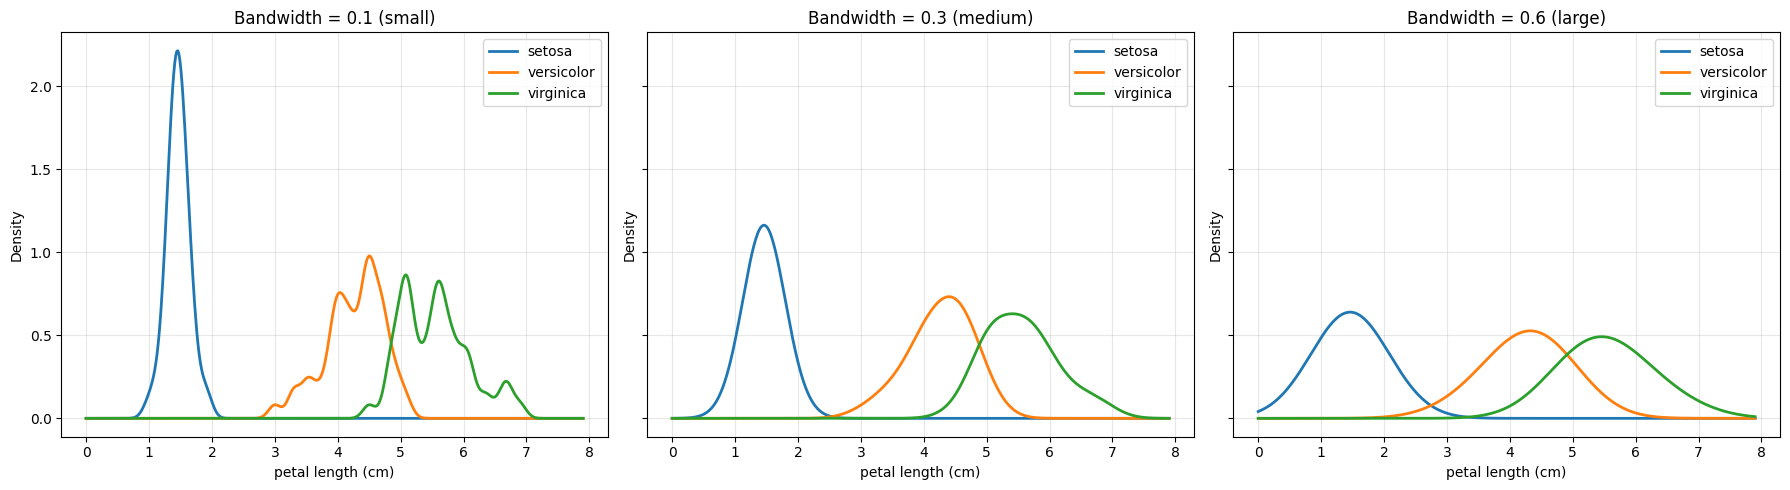

In [37]:
# TODO 10.3: Plot Parzen density estimates for different bandwidths

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, h) in zip(axes, bandwidths.items()):
    for cls in np.unique(y):
        class_samples = x_feature[y == cls]
        density = parzen_gaussian_1d(class_samples, grid, h)
        ax.plot(grid, density, label=class_names[cls], linewidth=2)

    ax.set_title(f'Bandwidth = {h} ({label})')
    ax.set_xlabel('petal length (cm)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Question 11(10pts)

Use 5-fold cross-validation to select the bandwidth. Use average log-likelihood as the selection criterion.

Plot log-likelihood versus bandwidth and identify the best bandwidth.

### Hint
For each fold, estimate the density of the validation samples using the training samples, then compute the average log-density.


In [38]:
# TODO 11.1: Define average log-likelihood for Parzen estimator

import numpy as np

def parzen_gaussian_1d(samples, grid, h):
    samples = np.asarray(samples).reshape(-1, 1)
    grid = np.asarray(grid).reshape(-1, 1)
    u = (grid - samples.T) / h
    kernel_vals = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (u ** 2))
    density = np.mean(kernel_vals, axis=1) / h
    return density

def average_log_likelihood(train_samples, val_samples, h):
    # Compute density estimate on validation samples (grid = val samples)
    density_vals = parzen_gaussian_1d(train_samples, val_samples, h)
    # Numerical stability: avoid log(0)
    density_vals = np.clip(density_vals, 1e-12, None)
    return np.mean(np.log(density_vals))


In [39]:
# TODO 11.2: Define bandwidth selection function

from sklearn.model_selection import KFold

def select_bandwidth_cv(data, bandwidths, n_folds=5):
    log_likelihoods = {h: [] for h in bandwidths}

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(data):
        train_samples = data[train_idx]
        val_samples = data[val_idx]

        for h in bandwidths:
            ll = average_log_likelihood(train_samples, val_samples, h)
            log_likelihoods[h].append(ll)

    # Compute mean LL per bandwidth
    avg_ll = {h: np.mean(vals) for h, vals in log_likelihoods.items()}
    return avg_ll


In [40]:
# TODO 11.3: Run bandwidth selection

# Feature: petal length (cm)
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data[:, iris.feature_names.index("petal length (cm)")]

bandwidths = np.linspace(0.05, 1.0, 20)   # 20 candidate bandwidths

avg_ll = select_bandwidth_cv(x, bandwidths)

# Convert to arrays for plotting
bw_list = np.array(list(avg_ll.keys()))
ll_list = np.array(list(avg_ll.values()))


Best bandwidth (by average log-likelihood): 0.15


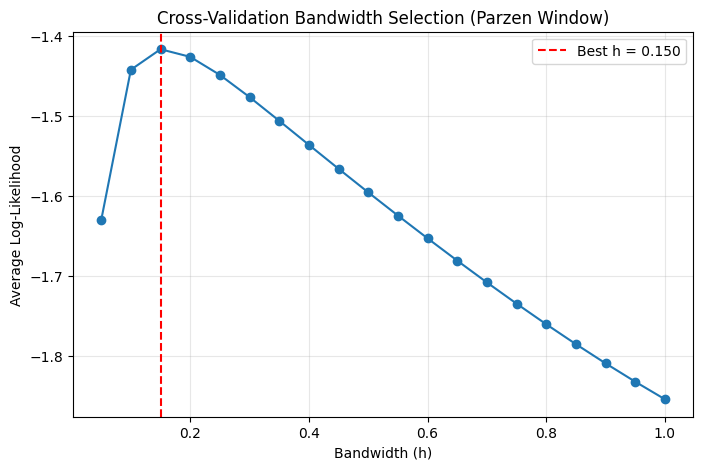

In [41]:
# TODO 11.4: Find and plot the best bandwidth

import matplotlib.pyplot as plt

best_h = bw_list[np.argmax(ll_list)]
print("Best bandwidth (by average log-likelihood):", best_h)

plt.figure(figsize=(8, 5))
plt.plot(bw_list, ll_list, marker="o")
plt.axvline(best_h, color='red', linestyle='--', label=f'Best h = {best_h:.3f}')
plt.xlabel("Bandwidth (h)")
plt.ylabel("Average Log-Likelihood")
plt.title("Cross-Validation Bandwidth Selection (Parzen Window)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Part 9: Density Estimation with Gaussian Mixture Model

## Question 12(10pts)

Using the two selected features `petal length (cm)` and `petal width (cm)`, train GMM models with 1 to 8 components.

For each model, compute AIC and BIC. Then use the AIC/BIC plots to select a suitable number of components.

### Hint
AIC and BIC are criteria that trade off model fit and model complexity. Lower values are usually better.


In [42]:
# TODO 12.1: Select features for GMM

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture

iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names

petal_length_idx = feature_names.index("petal length (cm)")
petal_width_idx = feature_names.index("petal width (cm)")

X_gmm = X[:, [petal_length_idx, petal_width_idx]]

print("Selected features:", feature_names[petal_length_idx], "and", feature_names[petal_width_idx])
print("X_gmm shape:", X_gmm.shape)


Selected features: petal length (cm) and petal width (cm)
X_gmm shape: (150, 2)


In [43]:
# TODO 12.2: Fit GMM models with different numbers of components

n_components_range = range(1, 9)

gmm_models = []
aic_values = []
bic_values = []

for n_components in n_components_range:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=42
    )
    
    gmm.fit(X_gmm)
    
    gmm_models.append(gmm)
    aic_values.append(gmm.aic(X_gmm))
    bic_values.append(gmm.bic(X_gmm))

aic_values = np.array(aic_values)
bic_values = np.array(bic_values)

print("AIC values:", aic_values)
print("BIC values:", bic_values)


AIC values: [555.58301426 331.46265584 304.69259184 300.31187654 298.15749237
 309.51408925 300.01426965 227.54461028]
BIC values: [570.63619073 364.57964407 355.87339184 369.5564883  385.46591589
 414.88632454 423.45031671 369.0444691 ]


In [44]:
# TODO 12.3: Select best model based on AIC and BIC

best_aic_index = np.argmin(aic_values)
best_bic_index = np.argmin(bic_values)

best_aic_components = list(n_components_range)[best_aic_index]
best_bic_components = list(n_components_range)[best_bic_index]

best_gmm_aic = gmm_models[best_aic_index]
best_gmm_bic = gmm_models[best_bic_index]

print("Best number of components based on AIC:", best_aic_components)
print("Best AIC value:", aic_values[best_aic_index])

print("Best number of components based on BIC:", best_bic_components)
print("Best BIC value:", bic_values[best_bic_index])


Best number of components based on AIC: 8
Best AIC value: 227.54461028128216
Best number of components based on BIC: 3
Best BIC value: 355.8733918391297


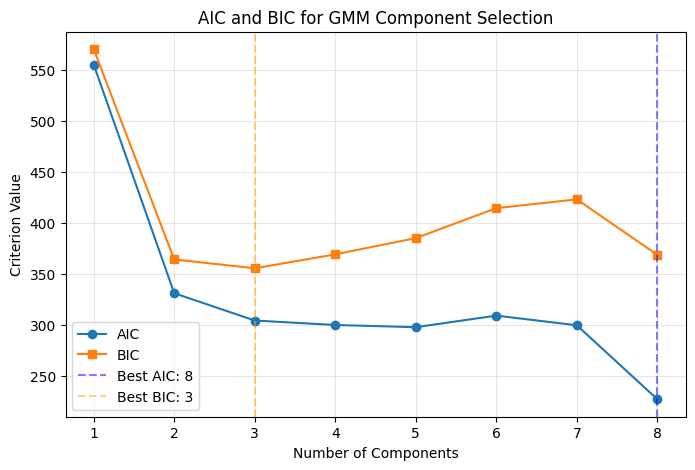

In [45]:
# TODO 12.4: Plot AIC and BIC

plt.figure(figsize=(8, 5))

plt.plot(list(n_components_range), aic_values, marker="o", label="AIC")
plt.plot(list(n_components_range), bic_values, marker="s", label="BIC")

plt.axvline(best_aic_components, color="blue", linestyle="--", alpha=0.5,
            label=f"Best AIC: {best_aic_components}")
plt.axvline(best_bic_components, color="orange", linestyle="--", alpha=0.5,
            label=f"Best BIC: {best_bic_components}")

plt.xlabel("Number of Components")
plt.ylabel("Criterion Value")
plt.title("AIC and BIC for GMM Component Selection")
plt.xticks(list(n_components_range))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Question 13(bonus)(10pts)


Train the GMM selected based on BIC using the two selected features. Then:

1. plot the training points in the two-dimensional feature space;
2. draw the density contours estimated by the GMM;
3. explain whether the selected number of components is consistent with the three-class structure of Iris.


In [46]:
# TODO 13.1: Train the selected GMM

from sklearn.mixture import GaussianMixture

best_n_components = 3  # selected based on BIC

gmm_selected = GaussianMixture(
    n_components=best_n_components,
    covariance_type="full",
    random_state=42
)

gmm_selected.fit(X_gmm)

print("Selected number of components:", best_n_components)
print("GMM trained successfully.")


Selected number of components: 3
GMM trained successfully.


In [47]:
# TODO 13.2: Create a grid for density visualization

x_min, x_max = X_gmm[:, 0].min() - 0.5, X_gmm[:, 0].max() + 0.5
y_min, y_max = X_gmm[:, 1].min() - 0.5, X_gmm[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# log-density from GMM
log_density = gmm_selected.score_samples(grid)
density = np.exp(log_density).reshape(xx.shape)

print("Grid shape:", xx.shape)
print("Density shape:", density.shape)


Grid shape: (300, 300)
Density shape: (300, 300)


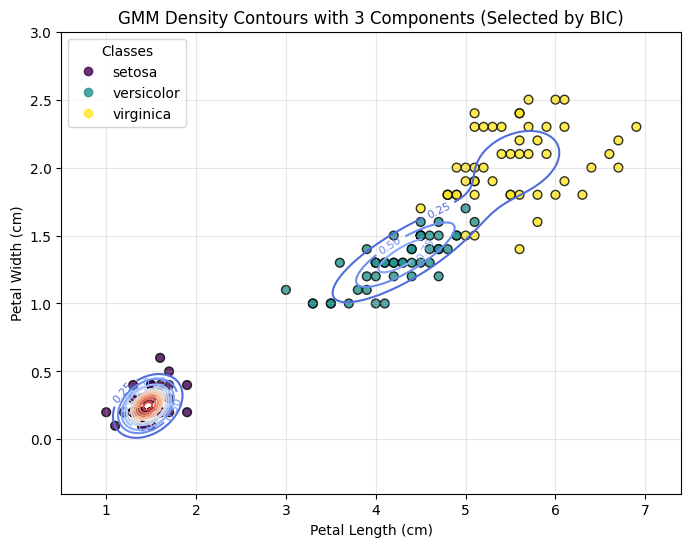

In [48]:
# TODO 13.3: Plot data and GMM density contours

plt.figure(figsize=(8, 6))

# plot training points
scatter = plt.scatter(
    X_gmm[:, 0], X_gmm[:, 1],
    c=y,
    cmap="viridis",
    s=40,
    edgecolor="k",
    alpha=0.8
)

# draw GMM density contours
contours = plt.contour(
    xx, yy, density,
    levels=12,
    cmap="coolwarm"
)

plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("GMM Density Contours with 3 Components (Selected by BIC)")
plt.grid(True, alpha=0.3)

# optional legend for iris classes
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Classes")

plt.show()
